# Online Retail — Revenue, Profitability & Business Analysis
## Project Goal
Analyze retail transactions to understand revenue, customer behavior, product performance, growth, profitability and business opportunities and provide data-driven recommendations to management.
## Topics Applied

Pandas & Data Cleaning, Revenue & Sales Analysis, Customer & Product Analysis, Time & Growth Analysis, Ratios & Averages, Weighted Average & CAGR, Cancellation Analysis, Business Mathematics, Data Visualization, Business Insights & Management Recommendation.


In [3]:
# Phase1 — Dataset Overview
# Task: Load the dataset and determine
import pandas as pd
df = pd.read_csv("Downloads/Online Retail Data Set.csv")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.0,United Kingdom


In [5]:
df.shape

(541909, 8)

In [7]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [11]:
# Checking Data Quality
# Missing values
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [17]:
# Missing percentage
print("Missing Values:")
(df.isnull().sum() / len(df) * 100).round(2)

Missing Values:


InvoiceNo       0.00
StockCode       0.00
Description     0.27
Quantity        0.00
InvoiceDate     0.00
UnitPrice       0.00
CustomerID     24.93
Country         0.00
dtype: float64

In [19]:
# Checking Duplicate Transactions
print("\nDuplicate Rows:")
df.duplicated().sum()


Duplicate Rows:


5268

In [21]:
# Negative quantities
print("\nNegative Quantity Records:")
print((df["Quantity"] < 0).sum())


Negative Quantity Records:
10624


In [23]:
# Zero or negative prices
print("\nZero/Negative Price Records:")
print((df["UnitPrice"] <= 0).sum())


Zero/Negative Price Records:
2517


In [31]:
print("Zero Price Records:", (df["UnitPrice"] == 0).sum())
print("Negative Price Records:", (df["UnitPrice"] < 0).sum())

Zero Price Records: 2515
Negative Price Records: 2


In [25]:
# Cancelled invoices
print("\nCancelled Invoices:")
print(df["InvoiceNo"].astype(str).str.startswith("C").sum())


Cancelled Invoices:
9288


In [27]:
cancelled = df[df["InvoiceNo"].astype(str).str.startswith("C")]
cancelled.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,12/1/10 9:41,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,12/1/10 9:49,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,12/1/10 10:24,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,12/1/10 10:24,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,12/1/10 10:24,0.29,17548.0,United Kingdom


In [33]:
# Data Quality Summary
print("Total Rows:", len(df))
print("Missing Description:", df["Description"].isna().sum())
print("Missing CustomerID:", df["CustomerID"].isna().sum())
print("Duplicate Rows:", df.duplicated().sum())
print("Zero/Negative Quantity:", (df["Quantity"] <= 0).sum())
print("Zero/Negative Price:", (df["UnitPrice"] <= 0).sum())
print("Cancelled Invoice Records:", df["InvoiceNo"].astype(str).str.startswith("C").sum())

Total Rows: 541909
Missing Description: 1454
Missing CustomerID: 135080
Duplicate Rows: 5268
Zero/Negative Quantity: 10624
Zero/Negative Price: 2517
Cancelled Invoice Records: 9288


In [67]:
# Phase 2- Revenue Analysis
# Business Context
# Understand:
# 1. Number of unique customers
# 2. Number of unique products
# 3. Countries represented in the dataset
# 4. Time period covered by the dataset
unique_customers = df["CustomerID"].nunique()
unique_products = df["StockCode"].nunique()
unique_countries = df["Country"].nunique()
start_date = df["InvoiceDate"].min()
end_date = df["InvoiceDate"].max()
print("Unique Customers:", unique_customers)
print("Unique Products:", unique_products)
print("Number of Countries:", unique_countries)
print("Start Date:", start_date)
print("End Date:", end_date)
# Interpretation
print("\nInterpretation:")
print(
    f"The dataset contains {unique_customers:,} unique customers "
    f"and {unique_products:,} unique products across "
    f"{unique_countries} countries. "
    f"The transactions cover the period from {start_date} "
    f"to {end_date}.")

Unique Customers: 4372
Unique Products: 4070
Number of Countries: 38
Start Date: 2010-12-01 08:26:00
End Date: 2011-12-09 12:50:00

Interpretation:
The dataset contains 4,372 unique customers and 4,070 unique products across 38 countries. The transactions cover the period from 2010-12-01 08:26:00 to 2011-12-09 12:50:00.


In [39]:
# Convert InvoiceDate to datetime
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
print("Start Date:", df["InvoiceDate"].min())
print("End Date:", df["InvoiceDate"].max())

Start Date: 2010-12-01 08:26:00
End Date: 2011-12-09 12:50:00


In [41]:
#Interpretation
print(
    f"\nThe dataset covers transactions from "
    f"{df['InvoiceDate'].min()} to {df['InvoiceDate'].max()}.")


The dataset covers transactions from 2010-12-01 08:26:00 to 2011-12-09 12:50:00.


In [69]:
# Revenue Calculation
# Calculate: Total Revenue, Total Units Sold, Number of Transactions, Average Transaction Value
df["Revenue"] = df["Quantity"] * df["UnitPrice"]
total_revenue = df["Revenue"].sum()
total_units = df["Quantity"].sum()
total_transactions = df["InvoiceNo"].nunique()
average_transaction_value = total_revenue / total_transactions
print("Total Revenue: ₹", round(total_revenue, 2))
print("Total Units Sold:", total_units)
print("Number of Transactions:", total_transactions)
print("Average Transaction Value: ₹", round(average_transaction_value, 2))
# Interpretation
print("\nInterpretation:")
print(
    f"The dataset generated total revenue of ₹{total_revenue:,.2f} "
    f"across {total_transactions:,} transactions, with "
    f"{total_units:,} units sold. The average transaction value "
    f"was ₹{average_transaction_value:,.2f}.")

Total Revenue: ₹ 9747747.93
Total Units Sold: 5176450
Number of Transactions: 25900
Average Transaction Value: ₹ 376.36

Interpretation:
The dataset generated total revenue of ₹9,747,747.93 across 25,900 transactions, with 5,176,450 units sold. The average transaction value was ₹376.36.


In [47]:
# Revenue by Time
# Create Date column
df["Date"] = df["InvoiceDate"].dt.date
# Create Month column
df["Month"] = df["InvoiceDate"].dt.to_period("M").astype(str)
# Daily revenue
daily_revenue = df.groupby("Date")["Revenue"].sum()
# Average daily revenue
average_daily_revenue = daily_revenue.mean()
# Monthly revenue
monthly_revenue = df.groupby("Month")["Revenue"].sum()
# Highest and lowest revenue months
highest_month = monthly_revenue.idxmax()
lowest_month = monthly_revenue.idxmin()
print("Average Daily Revenue: ₹", round(average_daily_revenue, 2))
print("\nHighest Revenue Month:", highest_month)
print("Revenue: ₹", round(monthly_revenue.max(), 2))
print("\nLowest Revenue Month:", lowest_month)
print("Revenue: ₹", round(monthly_revenue.min(), 2))
# Interpretation
print("\nInterpretation:")
print(
    f"Average daily revenue was ₹{average_daily_revenue:,.2f}, "
    f"with the highest monthly revenue in {highest_month} "
    f"and the lowest monthly revenue in {lowest_month}.")

Average Daily Revenue: ₹ 31959.83

Highest Revenue Month: 2011-11
Revenue: ₹ 1461756.25

Lowest Revenue Month: 2011-12
Revenue: ₹ 433668.01

Interpretation:
Average daily revenue was ₹31,959.83, with the highest monthly revenue in 2011-11 and the lowest monthly revenue in 2011-12.


In [49]:
# Revenue by product
product_revenue = df.groupby("Description")["Revenue"].sum().sort_values(ascending=False)
# Top 10 products
top_products = product_revenue.head(10)
# Bottom 10 products
bottom_products = product_revenue.tail(10)
# Percentage contribution of top 10 products
top_10_product_contribution = (
    top_products.sum() / total_revenue
) * 100
print("Top 10 Products by Revenue:")
print(top_products)
print("\nBottom 10 Products by Revenue:")
print(bottom_products)
print(
    "\nTop 10 Products Revenue Contribution: ",
    round(top_10_product_contribution, 2),
    "%")
# Interpretation
print("\nInterpretation:")
print(
    f"The top 10 products generated ₹{top_products.sum():,.2f}, "
    f"representing {top_10_product_contribution:.2f}% of total revenue.")

Top 10 Products by Revenue:
Description
DOTCOM POSTAGE                        206245.48
REGENCY CAKESTAND 3 TIER              164762.19
WHITE HANGING HEART T-LIGHT HOLDER     99668.47
PARTY BUNTING                          98302.98
JUMBO BAG RED RETROSPOT                92356.03
RABBIT NIGHT LIGHT                     66756.59
POSTAGE                                66230.64
PAPER CHAIN KIT 50'S CHRISTMAS         63791.94
ASSORTED COLOUR BIRD ORNAMENT          58959.73
CHILLI LIGHTS                          53768.06
Name: Revenue, dtype: float64

Bottom 10 Products by Revenue:
Description
WOODEN BOX ADVENT CALENDAR           -45.700
CREAM SWEETHEART MAGAZINE RACK       -46.850
WHITE CHERRY LIGHTS                  -54.000
SAMPLES                            -3049.390
Discount                           -5696.220
Bank Charges                       -7175.639
CRUK Commission                    -7933.430
Adjust bad debt                   -11062.060
Manual                            -68671.640
A

In [51]:
# Interpretation
print("\nInterpretation:")
print(
    f"The top 10 product descriptions generated ₹{top_products.sum():,.2f}, "
    f"representing {top_10_product_contribution:.2f}% of total revenue. "
    f"However, some descriptions represent non-product items such as postage, "
    f"fees, discounts, and accounting adjustments. Therefore, product-level "
    f"performance should be interpreted carefully and will be refined during "
    f"the data-cleaning stage.")


Interpretation:
The top 10 product descriptions generated ₹970,842.11, representing 9.96% of total revenue. However, some descriptions represent non-product items such as postage, fees, discounts, and accounting adjustments. Therefore, product-level performance should be interpreted carefully and will be refined during the data-cleaning stage.


In [63]:
# Revenue by country
country_revenue = (
    df.groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False))
# Top 10 countries
top_countries = country_revenue.head(10)
# Percentage contribution of top 10 countries
top_10_country_contribution = (
    top_countries.sum() / total_revenue
) * 100
print("Top 10 Countries by Revenue:")
print(top_countries)
print(
    "\nTop 10 Countries Revenue Contribution:",
    round(top_10_country_contribution, 2),
    "%")
# Interpretation
print("\nInterpretation:")
print(
    f"The top 10 countries generated ₹{top_countries.sum():,.2f}, "
    f"representing {top_10_country_contribution:.2f}% of total revenue. "
    f"The highest-revenue country was {top_countries.index[0]}.")

Top 10 Countries by Revenue:
Country
United Kingdom    8187806.364
Netherlands        284661.540
EIRE               263276.820
Germany            221698.210
France             197403.900
Australia          137077.270
Switzerland         56385.350
Spain               54774.580
Belgium             40910.960
Sweden              36595.910
Name: Revenue, dtype: float64

Top 10 Countries Revenue Contribution: 97.26 %

Interpretation:
The top 10 countries generated ₹9,480,590.90, representing 97.26% of total revenue. The highest-revenue country was United Kingdom.


In [65]:
# Interpretation
print("\nInterpretation:")
print(
    f"The top 10 countries generated ₹{top_countries.sum():,.2f}, "
    f"representing {top_10_country_contribution:.2f}% of total revenue. "
    f"The highest-revenue country was {top_countries.index[0]}, "
    f"which generated ₹{top_countries.iloc[0]:,.2f}.")


Interpretation:
The top 10 countries generated ₹9,480,590.90, representing 97.26% of total revenue. The highest-revenue country was United Kingdom, which generated ₹8,187,806.36.


In [71]:
# Phase 3 — Customer Analysis
# Customer Revenue
# Number of unique customers
unique_customers = df["CustomerID"].nunique()
# Revenue by customer
customer_revenue = (
    df.groupby("CustomerID")["Revenue"]
    .sum()
    .sort_values(ascending=False))
# Top 10 customers
top_customers = customer_revenue.head(10)
# Average revenue per customer
average_revenue_per_customer = customer_revenue.mean()
print("Unique Customers:", unique_customers)
print("\nTop 10 Customers by Revenue:")
print(top_customers)
print(
    "\nAverage Revenue per Customer: ₹",
    round(average_revenue_per_customer, 2))
# Interpretation
print("\nInterpretation:")
print(
    f"The business has {unique_customers:,} unique customers, "
    f"with an average revenue of ₹{average_revenue_per_customer:,.2f} "
    f"per customer.")

Unique Customers: 4372

Top 10 Customers by Revenue:
CustomerID
14646.0    279489.02
18102.0    256438.49
17450.0    187482.17
14911.0    132572.62
12415.0    123725.45
14156.0    113384.14
17511.0     88125.38
16684.0     65892.08
13694.0     62653.10
15311.0     59419.34
Name: Revenue, dtype: float64

Average Revenue per Customer: ₹ 1898.46

Interpretation:
The business has 4,372 unique customers, with an average revenue of ₹1,898.46 per customer.


In [73]:
# Customer Contribution
# Calculate:
# 1. Revenue generated by top 10 customers
# 2. Percentage contribution of top 10 customers
# 3. Customer revenue concentration
top_10_customer_revenue = customer_revenue.head(10).sum()
top_10_customer_contribution = (
    top_10_customer_revenue / total_revenue
) * 100
print("Top 10 Customers Revenue: ₹", round(top_10_customer_revenue, 2))
print(
    "Top 10 Customers Revenue Contribution:",
    round(top_10_customer_contribution, 2),
    "%")
# Interpretation
print("\nInterpretation:")
print(
    f"The top 10 customers contributed "
    f"{top_10_customer_contribution:.2f}% of total revenue.")

Top 10 Customers Revenue: ₹ 1369181.79
Top 10 Customers Revenue Contribution: 14.05 %

Interpretation:
The top 10 customers contributed 14.05% of total revenue.


In [75]:
# Customer Purchasing Behavior
# Orders per customer
customer_orders = (
    df.groupby("CustomerID")["InvoiceNo"]
    .nunique()
    .sort_values(ascending=False))
# Average Order Value per customer
customer_aov = customer_revenue / customer_orders
# Top 10 customers by number of orders
top_order_customers = customer_orders.head(10)
# Average order value across customers
average_customer_aov = customer_aov.mean()
print("Top 10 Customers by Number of Orders:")
print(top_order_customers)
print("\nAverage Order Value per Customer: ₹", round(average_customer_aov, 2))
# Interpretation
print("\nInterpretation:")
print(
    f"Customers placed an average order value of "
    f"₹{average_customer_aov:,.2f}, with purchasing frequency "
    f"varying across customers.")

Top 10 Customers by Number of Orders:
CustomerID
14911.0    248
12748.0    224
17841.0    169
14606.0    128
13089.0    118
15311.0    118
12971.0     89
14527.0     86
13408.0     81
14646.0     77
Name: InvoiceNo, dtype: int64

Average Order Value per Customer: ₹ 315.88

Interpretation:
Customers placed an average order value of ₹315.88, with purchasing frequency varying across customers.


#### Phase 3 — Findings
 - 4,372 unique customers.
 - Top 10 customers contributed 14.05% of revenue.
 - Average revenue per customer: ₹1,898.46.
 - Highest-order customer placed 248 orders.

In [77]:
# Phase 4 — Product & Sales Performance
# Product Volume
# Units sold by product
product_quantity = (
    df.groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False))
# Top 10 products by quantity
top_volume_products = product_quantity.head(10)
# Top 10 products by revenue
top_revenue_products = product_revenue.head(10)
print("Top 10 Products by Units Sold:")
print(top_volume_products)
print("\nTop 10 Products by Revenue:")
print(top_revenue_products)
# Interpretation
print("\nInterpretation:")
print(
    f"The highest-volume product sold {top_volume_products.iloc[0]:,} units, "
    f"while the highest-revenue product generated "
    f"₹{top_revenue_products.iloc[0]:,.2f}.")

Top 10 Products by Units Sold:
Description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     53847
JUMBO BAG RED RETROSPOT               47363
ASSORTED COLOUR BIRD ORNAMENT         36381
POPCORN HOLDER                        36334
PACK OF 72 RETROSPOT CAKE CASES       36039
WHITE HANGING HEART T-LIGHT HOLDER    35317
RABBIT NIGHT LIGHT                    30680
MINI PAINT SET VINTAGE                26437
PACK OF 12 LONDON TISSUES             26315
PACK OF 60 PINK PAISLEY CAKE CASES    24753
Name: Quantity, dtype: int64

Top 10 Products by Revenue:
Description
DOTCOM POSTAGE                        206245.48
REGENCY CAKESTAND 3 TIER              164762.19
WHITE HANGING HEART T-LIGHT HOLDER     99668.47
PARTY BUNTING                          98302.98
JUMBO BAG RED RETROSPOT                92356.03
RABBIT NIGHT LIGHT                     66756.59
POSTAGE                                66230.64
PAPER CHAIN KIT 50'S CHRISTMAS         63791.94
ASSORTED COLOUR BIRD ORNAMENT          58959.73
CHILLI LIGHTS  

In [79]:
# Price vs Sales
# Product-level price and quantity
product_price_quantity = (
    df.groupby("Description")
    .agg(
        AveragePrice=("UnitPrice", "mean"),
        TotalQuantity=("Quantity", "sum")))
# Correlation between price and quantity
price_quantity_correlation = (
    product_price_quantity["AveragePrice"]
    .corr(product_price_quantity["TotalQuantity"]))
print("Price vs Sales Correlation:", round(price_quantity_correlation, 3))
# Interpretation
print("\nInterpretation:")
print(
    f"The correlation between average product price and sales volume "
    f"is {price_quantity_correlation:.3f}.")

Price vs Sales Correlation: -0.008

Interpretation:
The correlation between average product price and sales volume is -0.008.


In [81]:
# Revenue Contribution
# Top 10 product contribution
top_product_contribution = (
    top_products.sum() / total_revenue
) * 100
# Top 10 country contribution
top_country_contribution = (
    top_countries.sum() / total_revenue
) * 100
# Top 10 customer contribution
top_customer_contribution = (
    top_customers.sum() / total_revenue
) * 100
print(
    "Top 10 Products Contribution:",
    round(top_product_contribution, 2),
    "%")
print(
    "Top 10 Countries Contribution:",
    round(top_country_contribution, 2),
    "%")
print(
    "Top 10 Customers Contribution:",
    round(top_customer_contribution, 2),
    "%")
# Interpretation
print("\nInterpretation:")
print(
    f"The top 10 products, countries, and customers contributed "
    f"{top_product_contribution:.2f}%, "
    f"{top_country_contribution:.2f}%, and "
    f"{top_customer_contribution:.2f}% of total revenue respectively.")

Top 10 Products Contribution: 9.96 %
Top 10 Countries Contribution: 97.26 %
Top 10 Customers Contribution: 14.05 %

Interpretation:
The top 10 products, countries, and customers contributed 9.96%, 97.26%, and 14.05% of total revenue respectively.


#### Phase 4 — Findings
 - Top 10 products: 9.96% of revenue.
 - Top-volume product: 53,847 units.
 - Price-volume correlation: -0.008.
 - Product and revenue leaders differ.

#### Phase 5 - Business Mathematics 

In [87]:
# Business Ratios
# Revenue per transaction
revenue_per_transaction = total_revenue / total_transactions
# Units per transaction
units_per_transaction = total_units / total_transactions
# Revenue per customer
revenue_per_customer = total_revenue / unique_customers
# Revenue per unit
revenue_per_unit = total_revenue / total_units
print("Revenue per Transaction: ₹", round(revenue_per_transaction, 2))
print("Units per Transaction:", round(units_per_transaction, 2))
print("Revenue per Customer: ₹", round(revenue_per_customer, 2))
print("Revenue per Unit: ₹", round(revenue_per_unit, 2))
# Interpretation
print("\nInterpretation:")
print(
    f"Each transaction generated ₹{revenue_per_transaction:,.2f} "
    f"on average and contained {units_per_transaction:.2f} units.")

Revenue per Transaction: ₹ 376.36
Units per Transaction: 199.86
Revenue per Customer: ₹ 2229.59
Revenue per Unit: ₹ 1.88

Interpretation:
Each transaction generated ₹376.36 on average and contained 199.86 units.


In [91]:
# Finding Averages
# Average Unit Price
average_unit_price = df["UnitPrice"].mean()
# Average Quantity per transaction
average_quantity_per_transaction = total_units / total_transactions
# Average Order Value
average_order_value = total_revenue / total_transactions
# Average Revenue per Customer
average_revenue_per_customer = total_revenue / unique_customers
print("Average Unit Price: ₹", round(average_unit_price, 2))
print(
    "Average Quantity per Transaction:",
    round(average_quantity_per_transaction, 2))
print("Average Order Value: ₹", round(average_order_value, 2))
print(
    "Average Revenue per Customer: ₹",
    round(average_revenue_per_customer, 2))
# Interpretation
print("\nInterpretation:")
print(
    f"The average unit price was ₹{average_unit_price:,.2f}, "
    f"while the average order value was ₹{average_order_value:,.2f}.")

Average Unit Price: ₹ 4.61
Average Quantity per Transaction: 199.86
Average Order Value: ₹ 376.36
Average Revenue per Customer: ₹ 2229.59

Interpretation:
The average unit price was ₹4.61, while the average order value was ₹376.36.


In [93]:
# Weighted Average
# Simple average UnitPrice
simple_average_price = df["UnitPrice"].mean()
# Weighted average UnitPrice
weighted_average_price = (
    (df["UnitPrice"] * df["Quantity"]).sum()
    / df["Quantity"].sum())
# Difference between the two averages
price_difference = weighted_average_price - simple_average_price
print("Simple Average Unit Price: ₹", round(simple_average_price, 2))
print("Weighted Average Unit Price: ₹", round(weighted_average_price, 2))
print("Difference: ₹", round(price_difference, 2))
# Interpretation
print("\nInterpretation:")
print(
    f"The simple average price was ₹{simple_average_price:,.2f}, "
    f"while the weighted average price was ₹{weighted_average_price:,.2f}.")

Simple Average Unit Price: ₹ 4.61
Weighted Average Unit Price: ₹ 1.88
Difference: ₹ -2.73

Interpretation:
The simple average price was ₹4.61, while the weighted average price was ₹1.88.


In [97]:
# Customer Growth
# Monthly unique customer
monthly_customers = (
    df.groupby("Month")["CustomerID"]
    .nunique()
    .sort_index())
# Month-over-month customer growth
customer_growth = monthly_customers.pct_change() * 100
print("Monthly Customer Growth (%):")
print(customer_growth.round(2))
# Interpretation
print("\nInterpretation:")
print(
    f"Monthly customer growth was highest in "
    f"{customer_growth.idxmax()} at {customer_growth.max():.2f}%.")

Monthly Customer Growth (%):
Month
2010-12      NaN
2011-01   -17.41
2011-02     1.92
2011-03    27.82
2011-04   -11.86
2011-05    20.02
2011-06    -2.59
2011-07    -5.52
2011-08    -1.31
2011-09    32.86
2011-10     9.45
2011-11    20.07
2011-12   -59.91
Name: CustomerID, dtype: float64

Interpretation:
Monthly customer growth was highest in 2011-09 at 32.86%.


In [99]:
# CAGR
start_revenue = monthly_revenue.iloc[0]
end_revenue = monthly_revenue.iloc[-1]
start_date = df["InvoiceDate"].min()
end_date = df["InvoiceDate"].max()
years = (end_date - start_date).days / 365
revenue_cagr = (
    (end_revenue / start_revenue) ** (1 / years) - 1
) * 100
print("Starting Revenue: ₹", round(start_revenue, 2))
print("Ending Revenue: ₹", round(end_revenue, 2))
print("Period (Years):", round(years, 2))
print("Revenue CAGR:", round(revenue_cagr, 2), "%")
# Interpretation
print("\nInterpretation:")
print(
    f"The calculated revenue CAGR was {revenue_cagr:.2f}%, "
    f"but the dataset covers only about {years:.1f} year, "
    f"so CAGR should be interpreted cautiously.")

Starting Revenue: ₹ 748957.02
Ending Revenue: ₹ 433668.01
Period (Years): 1.02
Revenue CAGR: -41.41 %

Interpretation:
The calculated revenue CAGR was -41.41%, but the dataset covers only about 1.0 year, so CAGR should be interpreted cautiously.


#### Phase 5 — Findings
 - Revenue per transaction: ₹376.36.
 - Revenue per customer: ₹2,229.59.
 - Weighted average price: ₹1.88 vs simple average ₹4.61.
 - Highest revenue growth: 49.37% in September 2011.
 - Highest customer growth: 32.86% in September 2011.
 - Revenue CAGR: -41.41%, but cautiously interpreted due to the short period.

#### Phase 6- Cancellation Analysis

In [103]:
# Cancelled invoice records
cancelled_records = df["InvoiceNo"].astype(str).str.startswith("C")
cancelled_transactions = df.loc[cancelled_records, "InvoiceNo"].nunique()
# Cancellation percentage
cancellation_percentage = (
    cancelled_transactions / total_transactions
) * 100
# Cancelled revenue
cancelled_revenue = (
    df.loc[cancelled_records, "Revenue"].sum())
print("Cancelled Transactions:", cancelled_transactions)
print(
    "Cancellation Percentage:",
    round(cancellation_percentage, 2),
    "%")
print("Cancelled Revenue: ₹", round(cancelled_revenue, 2))
# Interpretation
print("\nInterpretation:")
print(
    f"There were {cancelled_transactions:,} cancelled transactions, "
    f"representing {cancellation_percentage:.2f}% of total transactions.")

Cancelled Transactions: 3836
Cancellation Percentage: 14.81 %
Cancelled Revenue: ₹ -896812.49

Interpretation:
There were 3,836 cancelled transactions, representing 14.81% of total transactions.


In [107]:
# Net Revenue
# Gross Revenue
gross_revenue = df.loc[~cancelled_records, "Revenue"].sum()
# Returns/Cancellations
cancelled_revenue = df.loc[cancelled_records, "Revenue"].sum()
# Net Revenue
net_revenue = gross_revenue + cancelled_revenue
# Impact of cancellations on revenue
cancellation_impact = (
    abs(cancelled_revenue) / gross_revenue
) * 100
print("Gross Revenue: ₹", round(gross_revenue, 2))
print("Cancelled/Returned Revenue: ₹", round(cancelled_revenue, 2))
print("Net Revenue: ₹", round(net_revenue, 2))
print(
    "Cancellation Impact:",
    round(cancellation_impact, 2),
    "%")
# Interpretation
print("\nInterpretation:")
print(
    f"After accounting for cancellations, net revenue was "
    f"₹{net_revenue:,.2f}, with cancellations reducing "
    f"gross revenue by {cancellation_impact:.2f}%.")

Gross Revenue: ₹ 10644560.42
Cancelled/Returned Revenue: ₹ -896812.49
Net Revenue: ₹ 9747747.93
Cancellation Impact: 8.43 %

Interpretation:
After accounting for cancellations, net revenue was ₹9,747,747.93, with cancellations reducing gross revenue by 8.43%.


#### Phase 6 — Findings
 - 3,836 cancelled transactions.
 - Cancellation rate: 14.81%.
 - Cancellations reduced gross revenue by 8.43%.
 - Net revenue: ₹9,747,747.93.

#### Phase 7 — Profitability

In [115]:
# Profitability Limitations
# Revenue
revenue = df["Revenue"].sum()
# Cost information
cost_available = False
print("Revenue: ₹", round(revenue, 2))
print("Cost Data Available:", cost_available)
# Interpretation
print("\nInterpretation:")
print(
    "Actual profit and profit margin cannot be calculated because "
    "the dataset does not contain cost information such as COGS.")

Revenue: ₹ 9747747.93
Cost Data Available: False

Interpretation:
Actual profit and profit margin cannot be calculated because the dataset does not contain cost information such as COGS.


#### Phase 7 — Finding
 - Revenue can be analyzed, but actual profitability cannot be determined without cost data.

#### Phase 8 - Visualization

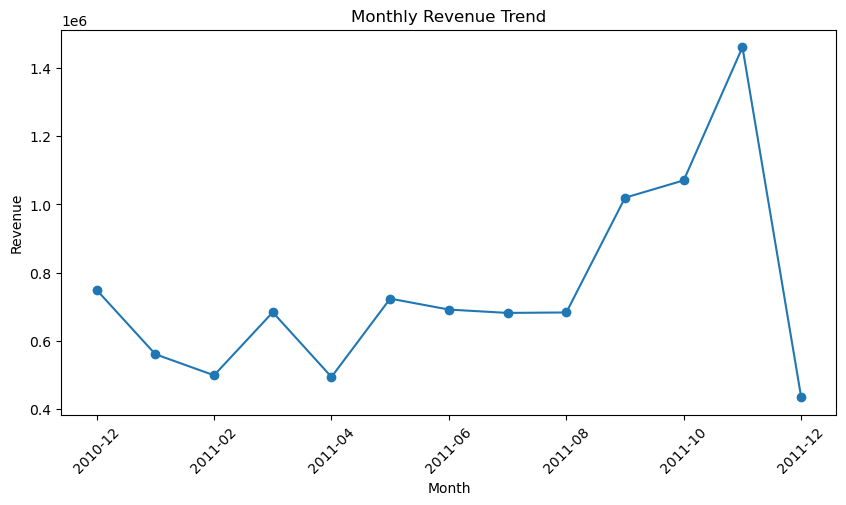

In [133]:
# Monthly Revenue Trend
import matplotlib.pyplot as plt
monthly_revenue = (
    df.groupby("Month")["Revenue"]
    .sum())
monthly_revenue.plot(
    kind="line",
    figsize=(10, 5),
    marker="o",
    title="Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

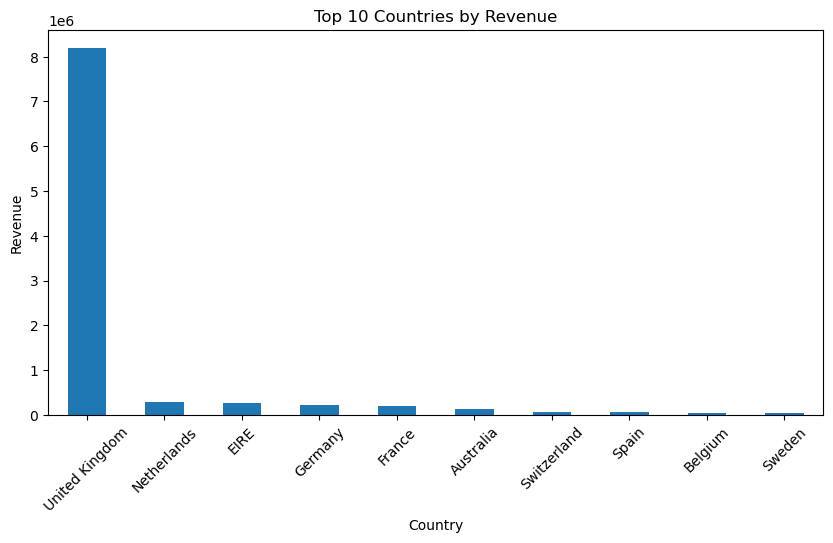

In [135]:
# Revenue by Country
country_revenue = (
    df.groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False))
top_10_countries = country_revenue.head(10)
top_10_countries.plot(
    kind="bar",
    figsize=(10, 5),
    title="Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

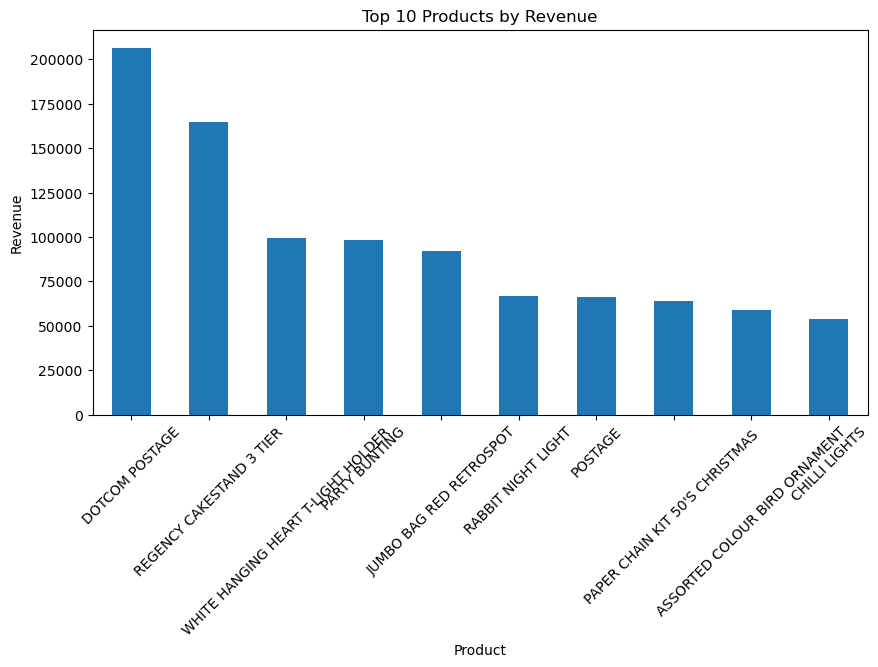

In [137]:
# Revenue by Product
product_revenue = (
    df.groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False))
top_10_products = product_revenue.head(10)
top_10_products.plot(
    kind="bar",
    figsize=(10, 5),
    title="Top 10 Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

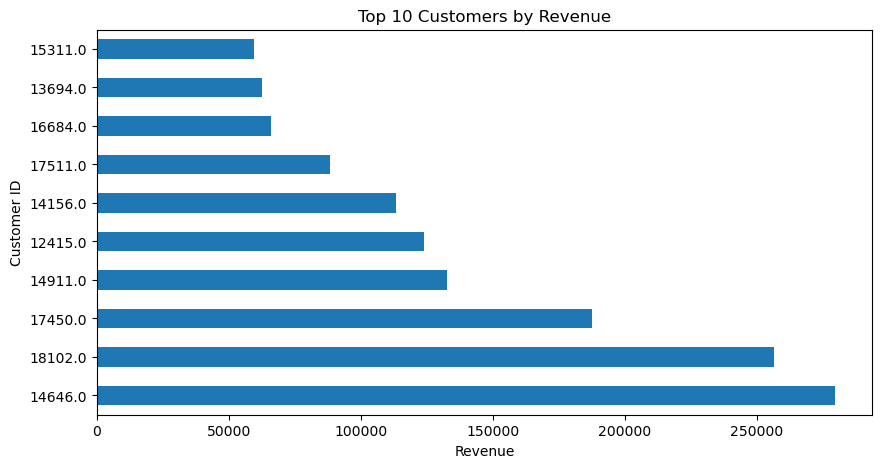

In [139]:
# Top Customers by Revenue
customer_revenue = (
    df.groupby("CustomerID")["Revenue"]
    .sum()
    .sort_values(ascending=False))
top_10_customers = customer_revenue.head(10)
top_10_customers.plot(
    kind="barh",
    figsize=(10, 5),
    title="Top 10 Customers by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Customer ID")
plt.show()

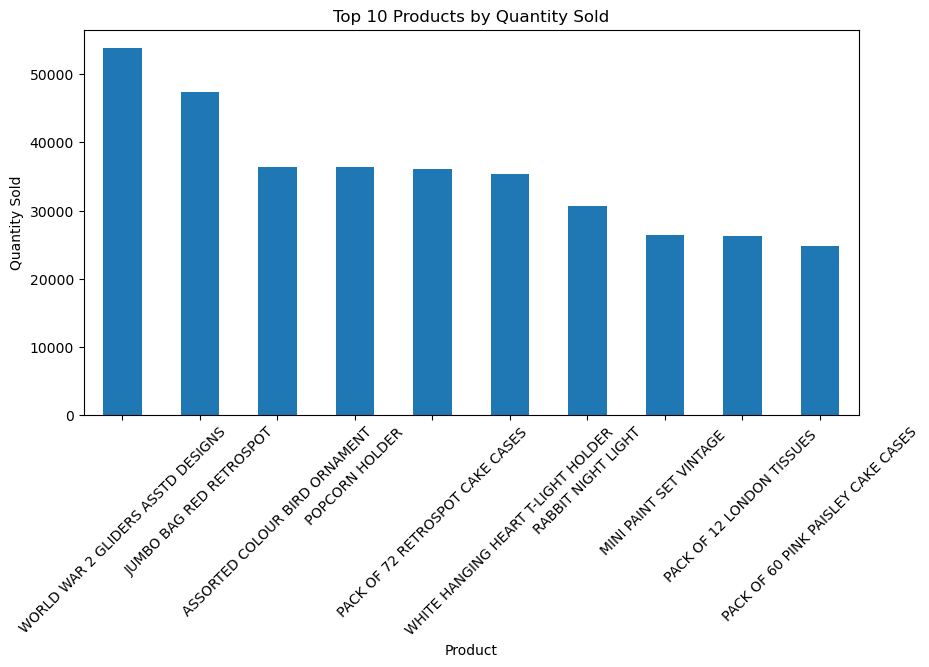

In [141]:
# Top Products by Quantity
product_quantity = (
    df.groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False))
top_10_quantity = product_quantity.head(10)
top_10_quantity.plot(
    kind="bar",
    figsize=(10, 5),
    title="Top 10 Products by Quantity Sold")
plt.xlabel("Product")
plt.ylabel("Quantity Sold")
plt.xticks(rotation=45)
plt.show()

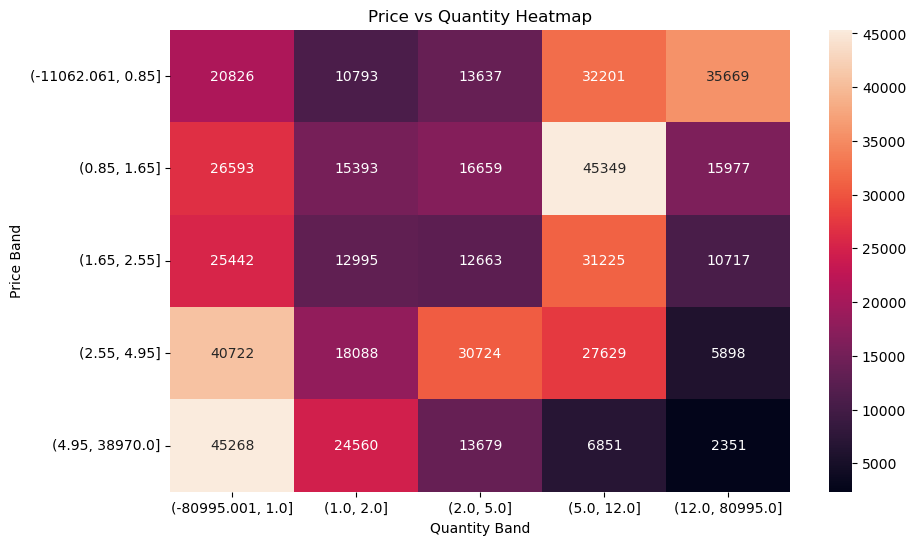

In [149]:
# Price vs Quantity
import seaborn as sns
price_quantity = df[["UnitPrice", "Quantity"]].copy()
price_quantity["PriceBand"] = pd.qcut(
    price_quantity["UnitPrice"],
    5,
    duplicates="drop")
price_quantity["QuantityBand"] = pd.qcut(
    price_quantity["Quantity"],
    5,
    duplicates="drop")
heatmap_data = pd.crosstab(
    price_quantity["PriceBand"],
    price_quantity["QuantityBand"])
plt.figure(figsize=(10, 6))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt="d")
plt.title("Price vs Quantity Heatmap")
plt.xlabel("Quantity Band")
plt.ylabel("Price Band")
plt.show()

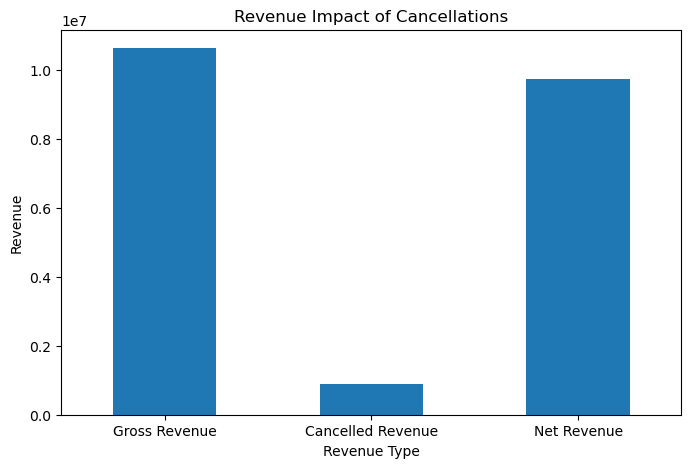

In [153]:
# Cancellation Impact
cancellation_data = pd.Series({
    "Gross Revenue": gross_revenue,
    "Cancelled Revenue": abs(cancelled_revenue),
    "Net Revenue": net_revenue})
cancellation_data.plot(
    kind="bar",
    figsize=(8, 5),
    title="Revenue Impact of Cancellations")
plt.xlabel("Revenue Type")
plt.ylabel("Revenue")
plt.xticks(rotation=0)
plt.show()

#### Phase 8 — Findings
 - Revenue showed noticeable monthly fluctuations, with November having the highest revenue.
 - United Kingdom was the dominant revenue market.
 - Top products and customers showed clear revenue differences.
 - High-volume products were not always the highest-revenue products.
 - The price–quantity heatmap showed sales concentrated across different price and quantity ranges.
 - Cancellations had a significant impact, reducing gross revenue by 8.43%.

#### Phase 9 — Business Insights

In [178]:
# 1. Strongest Revenue Drivers
top_country = country_revenue.idxmax()
top_country_revenue = country_revenue.max()
top_product = product_revenue.idxmax()
top_product_revenue = product_revenue.max()
print("Top Revenue Country:", top_country)
print("Revenue: ₹", round(top_country_revenue, 2))
print("\nTop Revenue Product:", top_product)
print("Revenue: ₹", round(top_product_revenue, 2))
# Insight
print("\nInsight:")
print(
    f"The United Kingdom was the strongest revenue market, "
    f"while {top_product} generated the highest product revenue.")

Top Revenue Country: United Kingdom
Revenue: ₹ 8187806.36

Top Revenue Product: DOTCOM POSTAGE
Revenue: ₹ 206245.48

Insight:
The United Kingdom was the strongest revenue market, while DOTCOM POSTAGE generated the highest product revenue.


In [180]:
# 2. Biggest Product & Market Opportunities
physical_products = product_revenue[
    ~product_revenue.index.str.contains(
        "POSTAGE|FEE|BANK CHARGES|DISCOUNT|COMMISSION|MANUAL|BAD DEBT",
        case=False,
        na=False)]
top_product_opportunity = physical_products.idxmax()
top_product_opportunity_revenue = physical_products.max()
international_revenue = country_revenue.drop("United Kingdom")
top_market_opportunity = international_revenue.idxmax()
top_market_opportunity_revenue = international_revenue.max()
print("Top Physical Product:", top_product_opportunity)
print("Revenue: ₹", round(top_product_opportunity_revenue, 2))
print("\nTop International Market:", top_market_opportunity)
print("Revenue: ₹", round(top_market_opportunity_revenue, 2))
# Insight
print("\nInsight:")
print(
    f"{top_product_opportunity} was the highest-revenue physical product, "
    f"while {top_market_opportunity} was the strongest international market.")

Top Physical Product: REGENCY CAKESTAND 3 TIER
Revenue: ₹ 164762.19

Top International Market: Netherlands
Revenue: ₹ 284661.54

Insight:
REGENCY CAKESTAND 3 TIER was the highest-revenue physical product, while Netherlands was the strongest international market.


In [182]:
# 3. Revenue Concentration & Risk
top_country_contribution = (
    country_revenue.head(10).sum() / total_revenue
) * 100
top_customer_contribution = (
    customer_revenue.head(10).sum() / total_revenue
) * 100
top_product_contribution = (
    product_revenue.head(10).sum() / total_revenue
) * 100
print("Top 10 Countries Contribution:", round(top_country_contribution, 2), "%")
print("Top 10 Customers Contribution:", round(top_customer_contribution, 2), "%")
print("Top 10 Products Contribution:", round(top_product_contribution, 2), "%")
# Insight
print("\nInsight:")
print(
    f"Revenue is highly concentrated geographically, with the top 10 countries "
    f"contributing {top_country_contribution:.2f}% of total revenue.")

Top 10 Countries Contribution: 97.26 %
Top 10 Customers Contribution: 14.05 %
Top 10 Products Contribution: 9.96 %

Insight:
Revenue is highly concentrated geographically, with the top 10 countries contributing 97.26% of total revenue.


In [184]:
# 4.Cancellation & Return Risk
cancellation_rate = (
    cancelled_transactions / total_transactions
) * 100
cancellation_impact = (
    abs(cancelled_revenue) / gross_revenue
) * 100
print("Cancellation Rate:", round(cancellation_rate, 2), "%")
print("Revenue Impact:", round(cancellation_impact, 2), "%")
# Insight
print("\nInsight:")
print(
    f"Cancellations affected {cancellation_rate:.2f}% of transactions "
    f"and reduced gross revenue by {cancellation_impact:.2f}%.")

Cancellation Rate: 14.81 %
Revenue Impact: 8.43 %

Insight:
Cancellations affected 14.81% of transactions and reduced gross revenue by 8.43%.


In [186]:
# 5.Revenue Growth & Decline
monthly_growth = monthly_revenue.pct_change() * 100
highest_growth_month = monthly_growth.idxmax()
highest_growth = monthly_growth.max()
largest_decline_month = monthly_growth.idxmin()
largest_decline = monthly_growth.min()
print("Highest Revenue Growth Month:", highest_growth_month)
print("Growth:", round(highest_growth, 2), "%")
print("\nLargest Revenue Decline Month:", largest_decline_month)
print("Decline:", round(largest_decline, 2), "%")
# Insight
print("\nInsight:")
print(
    f"Revenue growth was strongest in {highest_growth_month} at "
    f"{highest_growth:.2f}%, while the largest decline occurred in "
    f"{largest_decline_month} at {largest_decline:.2f}%.")

Highest Revenue Growth Month: 2011-09
Growth: 49.37 %

Largest Revenue Decline Month: 2011-12
Decline: -70.33 %

Insight:
Revenue growth was strongest in 2011-09 at 49.37%, while the largest decline occurred in 2011-12 at -70.33%.


In [176]:
# Overall Business Performance
print("Overall Business Performance:")
print(
    f"The business generated ₹{net_revenue:,.2f} in net revenue "
    f"from {total_transactions:,} transactions.")
print(
    f"Revenue was highly concentrated geographically, with the "
    f"top 10 countries contributing {top_country_contribution:.2f}% "
    f"of total revenue.")
print(
    f"Cancellations affected {cancellation_rate:.2f}% of transactions "
    f"and reduced gross revenue by {cancellation_impact:.2f}%.")
print(
    f"Revenue growth peaked at {highest_growth:.2f}% in "
    f"{highest_growth_month}, while the largest decline was "
    f"{largest_decline:.2f}% in {largest_decline_month}.")
print("\nInsight:")
print(
    "The business shows strong revenue generation but also significant "
    "geographic concentration, cancellation impact and monthly volatility.")

Overall Business Performance:
The business generated ₹9,747,747.93 in net revenue from 25,900 transactions.
Revenue was highly concentrated geographically, with the top 10 countries contributing 97.26% of total revenue.
Cancellations affected 14.81% of transactions and reduced gross revenue by 8.43%.
Revenue growth peaked at 49.37% in 2011-09, while the largest decline was -70.33% in 2011-12.

Insight:
The business shows strong revenue generation but also significant geographic concentration, cancellation impact and monthly volatility.


In [188]:
# Management Recommendations
print("Management Recommendations:\n")
print("1. Reduce geographic dependency by developing additional international markets.")
print("2. Investigate the causes of cancellations, which affected 14.81% of transactions.")
print("3. Focus on high-performing physical products such as REGENCY CAKESTAND 3 TIER.")
print("4. Monitor monthly revenue volatility and investigate major declines.")
print("5. Improve customer value through strategies that increase repeat purchases and order value.")
print("6. Collect COGS and operating cost data to enable proper profitability analysis.")

Management Recommendations:

1. Reduce geographic dependency by developing additional international markets.
2. Investigate the causes of cancellations, which affected 14.81% of transactions.
3. Focus on high-performing physical products such as REGENCY CAKESTAND 3 TIER.
4. Monitor monthly revenue volatility and investigate major declines.
5. Improve customer value through strategies that increase repeat purchases and order value.
6. Collect COGS and operating cost data to enable proper profitability analysis.
